# LeetCode #40: Combination Sum II

https://leetcode.com/problems/combination-sum-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(2^N \cdot N)$ | $O(N)$ |
| **Backtracking (DFS) + Sort, Prune & Skip-Duplicate** | $O(2^N)$ | $O(N)$ |

---

## Understanding the Methods

### Brute Force
Generate all $2^N$ subsets, filter those that sum to target, then de-duplicate using a set. Duplicate candidates in the input cause duplicate combinations in the output, so an extra O(N log N) sort-and-dedup pass is needed after the fact.

### Optimal: Backtracking (DFS) + Sort, Prune & Skip-Duplicate ★
Sort candidates first. DFS with three guards: (1) **prune** — break when `candidates[i] > remain`; (2) **no-reuse** — recurse with `i+1` (unlike #39 which uses `i`); (3) **skip-duplicate** — at each level, if `i > start && candidates[i] == candidates[i-1]`, skip to avoid generating the same combination twice. All three work together: sort makes duplicates adjacent so the skip is a single O(1) check per iteration.

**Why this is better than Brute Force:** Brute Force builds all $2^N$ subsets then de-dupes; DFS prunes over-target branches early and skips duplicates in-place, so each valid combination is produced exactly once with no post-processing.

**Constraints:**
* 1 <= candidates.length <= 100
* 1 <= candidates[i] <= 50
* 1 <= target <= 30

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> CombinationSum2(int[] candidates, int target) {
        var result = new List<IList<int>>();
        Array.Sort(candidates);
        Backtrack(candidates, target, 0, new List<int>(), result);
        return result;
    }

    private void Backtrack(int[] candidates, int remain, int start, List<int> path, IList<IList<int>> result) {
        if (remain == 0) { result.Add(new List<int>(path)); return; }
        for (int i = start; i < candidates.Length; i++) {
            // Prune: sorted array means all further candidates also exceed remain
            if (candidates[i] > remain) break;
            // Skip duplicate values at the same DFS level to avoid duplicate combinations
            if (i > start && candidates[i] == candidates[i - 1]) continue;
            path.Add(candidates[i]);
            // Pass i+1 (not i) — each element used at most once
            Backtrack(candidates, remain - candidates[i], i + 1, path, result);
            path.RemoveAt(path.Count - 1);
        }
    }
}

### Python

In [ ]:
class Solution:
    def combinationSum2(self, candidates: list[int], target: int) -> list[list[int]]:
        candidates.sort()
        result = []

        def backtrack(start: int, path: list[int], remain: int) -> None:
            if remain == 0:
                result.append(list(path))
                return
            for i in range(start, len(candidates)):
                # Prune: sorted array means all further candidates also exceed remain
                if candidates[i] > remain:
                    break
                # Skip duplicate values at the same DFS level to avoid duplicate combinations
                if i > start and candidates[i] == candidates[i - 1]:
                    continue
                path.append(candidates[i])
                # Pass i+1 (not i) — each element used at most once
                backtrack(i + 1, path, remain - candidates[i])
                path.pop()

        backtrack(0, [], target)
        return result

### Go

In [ ]:
func combinationSum2(candidates []int, target int) [][]int {
    sort.Ints(candidates)
    result := [][]int{}
    var backtrack func(start, remain int, path []int)
    backtrack = func(start, remain int, path []int) {
        if remain == 0 {
            combo := make([]int, len(path))
            copy(combo, path)
            result = append(result, combo)
            return
        }
        for i := start; i < len(candidates); i++ {
            // Prune: sorted array means all further candidates also exceed remain
            if candidates[i] > remain {
                break
            }
            // Skip duplicate values at the same DFS level to avoid duplicate combinations
            if i > start && candidates[i] == candidates[i-1] {
                continue
            }
            // Pass i+1 (not i) — each element used at most once
            backtrack(i+1, remain-candidates[i], append(path, candidates[i]))
        }
    }
    backtrack(0, target, []int{})
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn combination_sum2(mut candidates: Vec<i32>, target: i32) -> Vec<Vec<i32>> {
        candidates.sort();
        let mut result = Vec::new();
        Self::backtrack(&candidates, target, 0, &mut Vec::new(), &mut result);
        result
    }

    fn backtrack(candidates: &[i32], remain: i32, start: usize, path: &mut Vec<i32>, result: &mut Vec<Vec<i32>>) {
        if remain == 0 {
            result.push(path.clone());
            return;
        }
        for i in start..candidates.len() {
            // Prune: sorted array means all further candidates also exceed remain
            if candidates[i] > remain {
                break;
            }
            // Skip duplicate values at the same DFS level to avoid duplicate combinations
            if i > start && candidates[i] == candidates[i - 1] {
                continue;
            }
            path.push(candidates[i]);
            // Pass i+1 (not i) — each element used at most once
            Self::backtrack(candidates, remain - candidates[i], i + 1, path, result);
            path.pop();
        }
    }
}

## Example Scenarios

**1. Common Case**
**Input:** candidates = [10,1,2,7,6,1,5], target = 8
After sorting: [1,1,2,5,6,7,10]. At the first level, `i=1` is skipped because `candidates[1]==candidates[0]==1` and `i>start`. Valid combinations found: [1,1,6], [1,2,5], [1,7], [2,6]. Four unique results despite two `1`s in the input.

**2. Slightly Complex**
**Input:** candidates = [2,5,2,1,2], target = 5
After sorting: [1,2,2,2,5]. The three `2`s at positions 1,2,3 — only position 1 is ever chosen at each DFS level (positions 2 and 3 are skipped by the duplicate guard). Valid combinations: [1,2,2] and [5]. The skip-duplicate check (`i > start && candidates[i] == candidates[i-1]`) prevents [1,2₂,2₁] and [1,2₃,2₁] from being explored.

**3. Edge Case: Time Factor**
**Input:** candidates = [1,1,1,…,1] (100 ones), target = 30
After sorting: 100 ones. At level 0, only `candidates[0]=1` is chosen (positions 1–99 are all duplicates and skipped). At level 1 (start=1), only `candidates[1]=1` is chosen, etc. The duplicate skip reduces 100 choices per level to exactly 1, making the DFS a straight path of depth 30. Without the skip: $2^{100}$ subsets explored; with it: exactly 1 path of depth 30 → O(T) work.

**4. Edge Case: Space Factor**
**Input:** candidates = [1,2,3,…,30], target = 30
All distinct candidates in sorted order. The deepest valid path is [1,2,3,…] until sum reaches 30. Maximum path depth is bounded by the minimum candidate value: $\lfloor T / \min(c) \rfloor = 30$ frames. Each frame stores only `i`, `remain`, and the shared path reference — total auxiliary space $O(N)$ where $N$ is the path depth, at most $O(T)$.

**5. Almost-Impossible but Plausible**
**Input:** candidates = [1,1], target = 1
After sorting: [1,1]. At level 0: choose `candidates[0]=1`, remain=0 → capture [1]. Backtrack. Next: `i=1`, but `i(1) > start(0)` and `candidates[1]==candidates[0]` → skip. Result: [[1]]. Without the duplicate guard, [1] would appear twice — once from each `1`. The guard fires exactly here: same level, same value, position after the first occurrence.

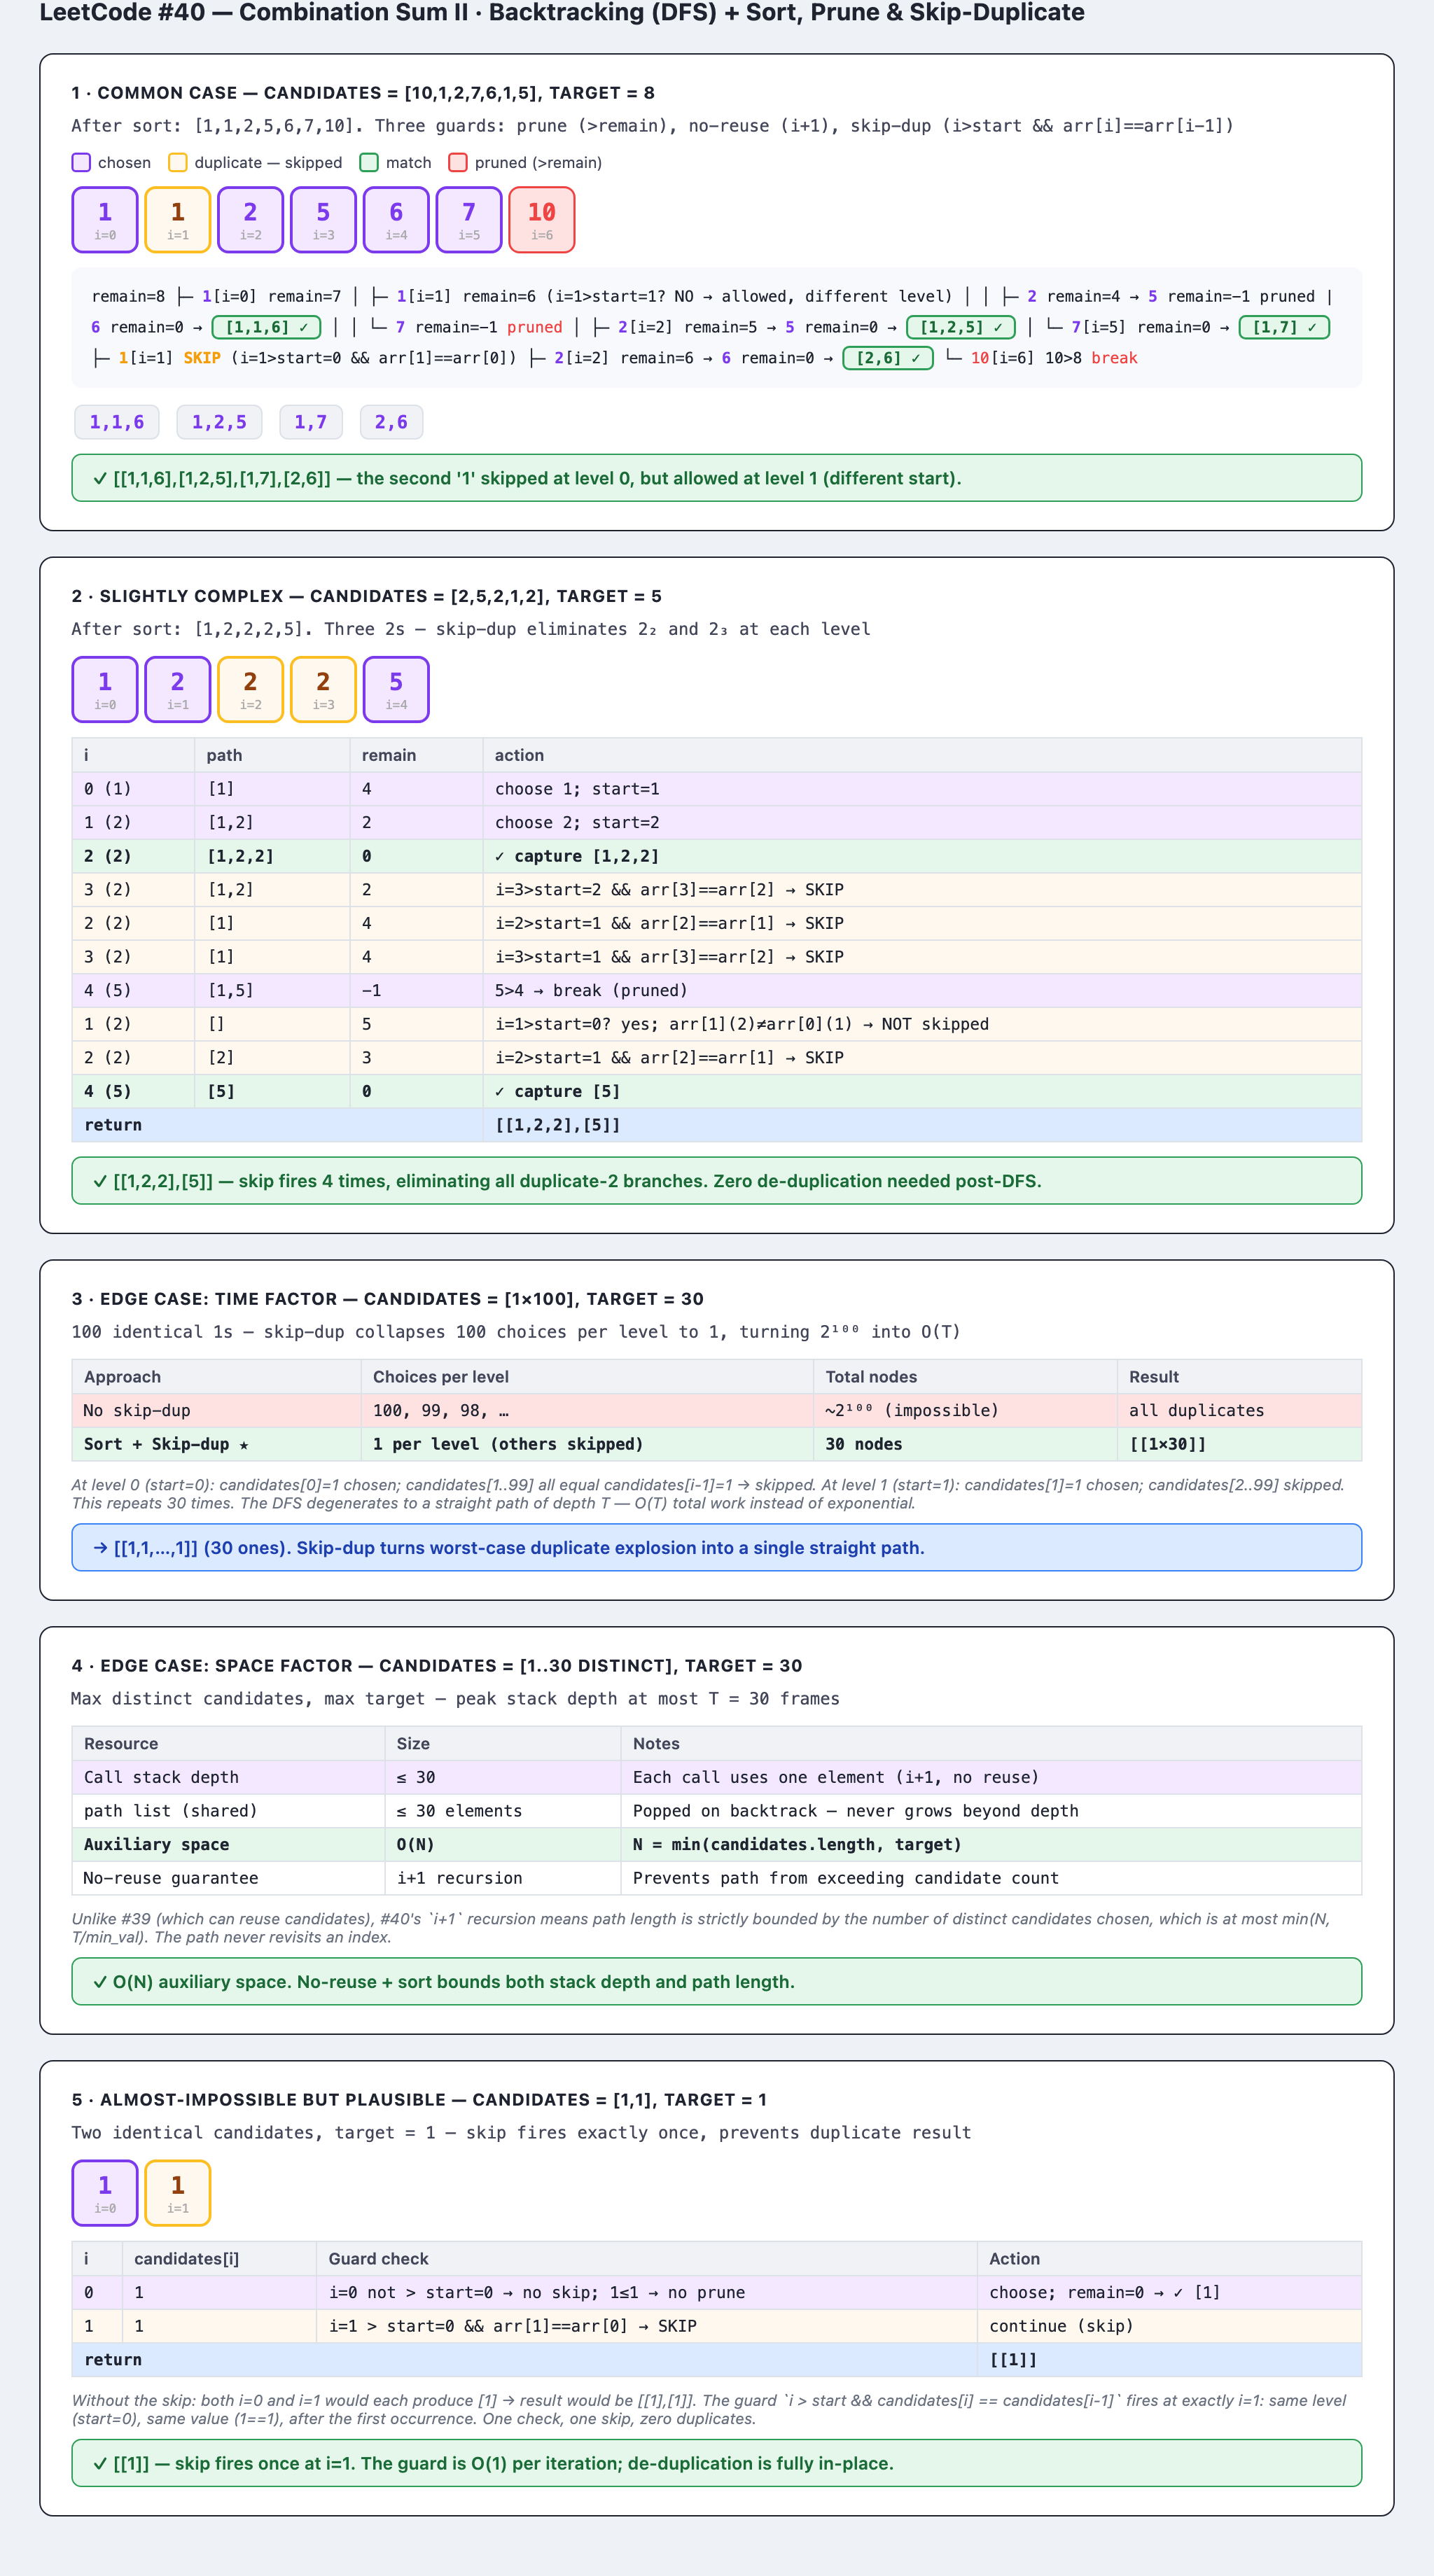